# Week 6 - Feature Engineering And Pipeline Selection

**Business question:** do engineered and train-selected non-leaky features improve CRMLS SingleFamilyResidence `ClosePrice` prediction enough to support retrospective valuation QA, pricing triage, and manual-review targeting?

The Week 6 analysis has five main objectives:

1. Add the newly available `CRMLSSold202606.csv` sold-property dataset.
2. Engineer explainable property features for size, layout, amenity intensity, carrying cost, and school-district geography.
3. Compare the original Week 5 feature set with the expanded Week 6 feature set.
4. Select the locked pipeline using May 2026 validation only.
5. Evaluate the locked winner on June 2026 without using June to revise the model.

The evaluation has two June views:

- **Comparable benchmark:** June in-range, restricted by training-defined target limits, used for Week 5 vs Week 6 comparison.
- **Operational robustness:** Full June, all eligible June SFR sales, used to show stricter real-world error exposure.

To maintain direct comparability with Week 5, the benchmark comparison uses the same training-defined in-range June population. Full-June performance is reported separately as an operational robustness evaluation.


### Technical Setup And Inputs

This notebook uses the June-refreshed Week 3 cleaned dataset and the Week 5 model results as the benchmark.

Aidan's Week 6 requirements reflected here:
- add interpretable feature engineering
- carry forward the school district layer
- retrain models with the updated feature set
- compare old vs new feature sets
- explain model and feature-selection strengths/weaknesses

Slack channel search was not discoverable in this environment, so the current thread and Week 6 screenshot are treated as the requirement source.

In [1]:
from pathlib import Path
import json
import sys
import textwrap
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "outputs" / "week3_preprocessing" / "crmls_sfr_quality_cleaned_202501_202606.csv"
WEEK5_METRICS_PATH = ROOT / "outputs" / "week5_model_comparison" / "week5_final_test_metrics.csv"
WEEK5_SEGMENT_PATH = ROOT / "outputs" / "week5_model_comparison" / "week5_segment_errors.csv"
WEEK5_TEST_PREDICTIONS_PATH = ROOT / "outputs" / "week5_model_comparison" / "week5_selected_model_test_predictions.csv"
OUTPUT_DIR = ROOT / "outputs" / "week6_feature_engineering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

from week6_model_pipeline import CRMLSFeaturePreprocessor, ColumnSelector, add_engineered_features

TARGET = "ClosePrice"
RANDOM_STATE = 42
VALIDATION_MONTH = "2026-05"
TEST_MONTH = "2026-06"
TRAIN_START_MONTH = "2025-02"
TRAIN_END_MONTH = "2026-04"
MISSINGNESS_LIMIT = 0.90

print("Data:", DATA_PATH)
print("Output:", OUTPUT_DIR)
print("Train:", TRAIN_START_MONTH, "to", TRAIN_END_MONTH, "| Validation:", VALIDATION_MONTH, "| Test:", TEST_MONTH)

Data: /Users/amyliu/Desktop/summer intern/outputs/week3_preprocessing/crmls_sfr_quality_cleaned_202501_202606.csv
Output: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering
Train: 2025-02 to 2026-04 | Validation: 2026-05 | Test: 2026-06


### Data Load And Scope Check

Only `Residential` / `SingleFamilyResidence` rows are eligible. Rows are not dropped blindly; the filters below are the explicit modeling population and target-date requirements.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, low_memory=False)
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df["close_month"] = pd.PeriodIndex(df["close_month"].astype(str), freq="M").astype(str)

df = df[
    df["PropertyType"].astype(str).str.strip().eq("Residential")
    & df["PropertySubType"].astype(str).str.strip().eq("SingleFamilyResidence")
    & df["CloseDate"].notna()
].copy()

school_rows = int(df["UnifiedSchoolDistrictName"].notna().sum())
print("Rows:", len(df))
print("Months:", df["close_month"].min(), "to", df["close_month"].max())
print("Rows with ClosePrice available:", int(df[TARGET].notna().sum()))
print("June max CloseDate:", df.loc[df["close_month"].eq(TEST_MONTH), "CloseDate"].max())
print("Unified school district matched rows:", school_rows)

Rows: 187750
Months: 2025-01 to 2026-06
Rows with ClosePrice available: 187750
June max CloseDate: 2026-06-30 00:00:00
Unified school district matched rows: 142197


## 1. What Changed In Week 6

These features are allowed because they describe property structure, carrying cost, or geographic market segmentation before model scoring.

| Feature | Why it helps pricing decisions |
| --- | --- |
| `log_living_area` | handles diminishing price effect of additional square footage |
| `log_lot_size_sqft` | reduces skew in lot-size effects |
| `bed_bath_ratio`, `bath_per_bedroom`, `total_bed_bath` | captures layout functionality beyond raw bed/bath counts |
| `garage_present`, `garage_per_bedroom` | captures parking utility, important in many California markets |
| `fireplaces_per_bedroom` | captures amenity intensity without over-weighting large homes |
| `association_fee_present` | separates HOA/fee properties from no-fee properties |
| `tax_per_living_sqft` | proxy for carrying cost and assessed-value intensity |
| school district frequency encoding | train-only geographic market-size signal produced by the fitted preprocessor |
| school district density fields | geographic segmentation, not causal school-quality claims |

Frequency encoding is useful but limited. It measures how often a category appears in training data, not whether that location is expensive. Week 7 should compare stronger location encodings, such as leakage-safe target encoding, CatBoost-style categorical handling, or spatial features from latitude and longitude.


### School District Layer Check

- The school-district fields are carried forward from the Week 3 spatial enrichment step.
- Week 3 uses property `Longitude` and `Latitude` to create geographic points, then spatially joins those points to official California Unified School District polygons.
- The spatial join code uses `EPSG:4326` property points and reprojects them to the school-boundary CRS before joining.
- Aggregate check: `142,197` of `187,750` eligible SFR rows are matched to a Unified School District, for a `75.74%` match rate.
- Interpretation: the method is directionally correct and the match rate is plausible, but this is not a full geospatial QA audit.
- Remaining QA need: verify duplicate polygon matches, inspect unmatched rows by county/city, and confirm boundary coverage for all California locations.

### Prediction Moment Caveat

This Week 6 notebook is a retrospective development experiment, not a final listing-date production model.

The current feature set includes close-date timing fields such as property age at close and closing-month seasonality. Those fields are known after the sale closes, so they are valid for retrospective model comparison but not valid for a listing-date prediction workflow.

For a true listing-time model, age and seasonality should be derived from ListingContractDate or a defined valuation date. TaxAnnualAmount and school-district fields also need a timing audit to confirm they were available at the scoring date.


In [3]:
df = add_engineered_features(df)

engineered_features = [
    "log_living_area", "log_lot_size_sqft", "bed_bath_ratio", "bath_per_bedroom",
    "total_bed_bath", "garage_present", "garage_per_bedroom", "fireplaces_per_bedroom",
    "association_fee_present", "tax_per_living_sqft",
]

missing_engineered = [col for col in engineered_features if col not in df.columns]
if missing_engineered:
    raise ValueError(f"Missing engineered features: {missing_engineered}")

print("Engineered feature count:", len(engineered_features))

Engineered feature count: 10


### Leakage Guardrail

Leakage fields are blocked before any candidate pipeline is trained. This prevents feature-selection methods from learning sale-process or target-derived information.


In [4]:
FORBIDDEN_FEATURES = {
    TARGET,
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice_to_ListPrice_ratio",
    "price_per_sqft_audit",
    "DaysOnMarket",
    "MlsStatus",
    "ContractStatusChangeDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "UnparsedAddress",
    "ListAgentEmail",
    "ListAgentAOR",
    "ListOfficeName",
    "BuyerOfficeName",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "BuyerAgentMlsId",
    "source_month",
    "split",
}

print("Defined leakage blocklist:", len(FORBIDDEN_FEATURES), "fields.")


Defined leakage blocklist: 23 fields.


In [5]:
X5_NUMERIC = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "LotSizeAcres", "LotSizeArea", "YearBuilt", "property_age_at_close",
    "bed_bath_ratio", "living_area_to_lot_ratio", "Latitude", "Longitude",
    "GarageSpaces", "ParkingTotal", "AssociationFee", "Stories", "MainLevelBedrooms",
    "UnifiedSchoolDistrictEnrollTotal", "UnifiedSchoolDistrictAreaSqMi",
    "UnifiedSchoolDistrictEnrollmentDensity", "close_month_sin", "close_month_cos",
]

X5_CATEGORICAL = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict",
    "UnifiedSchoolDistrictName", "UnifiedSchoolDistrictCounty",
    "UnifiedSchoolDistrictLocaleDesc", "Levels", "AssociationFeeFrequency", "StateOrProvince",
]

X5_BINARY = [
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN",
    "ViewYN_was_missing", "PoolPrivateYN_was_missing", "AttachedGarageYN_was_missing",
    "FireplaceYN_was_missing", "NewConstructionYN_was_missing",
    "flag_unified_school_district_missing",
]

print("Defined X5 baseline raw feature lists.")


Defined X5 baseline raw feature lists.


In [6]:
SCHOOL_NUMERIC = [
    "UnifiedSchoolDistrictEnrollTotal",
    "UnifiedSchoolDistrictAreaSqMi",
    "UnifiedSchoolDistrictEnrollmentDensity",
]

SCHOOL_CATEGORICAL = [
    "HighSchoolDistrict",
    "UnifiedSchoolDistrictName",
    "UnifiedSchoolDistrictCounty",
    "UnifiedSchoolDistrictLocaleDesc",
]

SCHOOL_BINARY = ["flag_unified_school_district_missing"]

X6_EXTRA_NUMERIC = [
    "log_living_area", "log_lot_size_sqft", "bath_per_bedroom", "total_bed_bath",
    "garage_per_bedroom", "fireplaces_per_bedroom", "tax_per_living_sqft",
]

X6_EXTRA_BINARY = ["garage_present", "association_fee_present"]

X5_NUMERIC_NO_SCHOOL = [col for col in X5_NUMERIC if col not in SCHOOL_NUMERIC]
X5_CATEGORICAL_NO_SCHOOL = [col for col in X5_CATEGORICAL if col not in SCHOOL_CATEGORICAL]
X5_BINARY_NO_SCHOOL = [col for col in X5_BINARY if col not in SCHOOL_BINARY]
X6_EXTRA_NUMERIC_NO_SCHOOL = list(X6_EXTRA_NUMERIC)

FEATURE_SPECS = {
    "X5_no_school": {
        "numeric": X5_NUMERIC_NO_SCHOOL,
        "categorical": X5_CATEGORICAL_NO_SCHOOL,
        "binary": X5_BINARY_NO_SCHOOL,
        "description": "Week 5 fixed feature set with school-district fields removed.",
    },
    "X5_fixed": {
        "numeric": X5_NUMERIC,
        "categorical": X5_CATEGORICAL,
        "binary": X5_BINARY,
        "description": "Week 5 fixed non-leaky feature set.",
    },
    "X6_engineered_no_school": {
        "numeric": list(dict.fromkeys(X5_NUMERIC_NO_SCHOOL + X6_EXTRA_NUMERIC_NO_SCHOOL)),
        "categorical": X5_CATEGORICAL_NO_SCHOOL,
        "binary": list(dict.fromkeys(X5_BINARY_NO_SCHOOL + X6_EXTRA_BINARY)),
        "description": "Week 6 engineered feature pool with school-district fields removed.",
    },
    "X6_engineered": {
        "numeric": list(dict.fromkeys(X5_NUMERIC + X6_EXTRA_NUMERIC)),
        "categorical": X5_CATEGORICAL,
        "binary": list(dict.fromkeys(X5_BINARY + X6_EXTRA_BINARY)),
        "description": "Week 6 expanded non-leaky feature pool with school-district fields and engineered property features.",
    },
}

for spec_name, spec in FEATURE_SPECS.items():
    raw_features = set(spec["numeric"] + spec["categorical"] + spec["binary"])
    leakage = sorted(raw_features.intersection(FORBIDDEN_FEATURES))
    if leakage:
        raise ValueError(f"{spec_name} contains leakage features: {leakage}")

print("Leakage guardrail passed for feature specs:", list(FEATURE_SPECS))

Leakage guardrail passed for feature specs: ['X5_no_school', 'X5_fixed', 'X6_engineered_no_school', 'X6_engineered']


## 2. Goal & Workflow

Train builds candidate pipelines. May validation chooses among completed pipelines. June is held for locked-pipeline evaluation only.

January 2025 is excluded from training to stay aligned with the Week 5 benchmark window. This keeps Week 5 and Week 6 comparisons methodologically comparable.


In [7]:
month = pd.PeriodIndex(df["close_month"].astype(str), freq="M")
train_raw = df[(month >= pd.Period(TRAIN_START_MONTH, freq="M")) & (month <= pd.Period(TRAIN_END_MONTH, freq="M"))].copy()
validation_raw = df[month == pd.Period(VALIDATION_MONTH, freq="M")].copy()
test_raw = df[month == pd.Period(TEST_MONTH, freq="M")].copy()

train = train_raw[train_raw[TARGET].notna()].sort_values("CloseDate").reset_index(drop=True).copy()
validation = validation_raw[validation_raw[TARGET].notna()].sort_values("CloseDate").reset_index(drop=True).copy()

if min(len(train), len(validation), len(test_raw)) == 0:
    raise ValueError("Train, validation, or June test partition is empty.")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows_before_filter": [len(train_raw), len(validation_raw), len(test_raw)],
    "rows_with_closeprice": [len(train), len(validation), int(test_raw[TARGET].notna().sum())],
    "start_month": [train["close_month"].min(), validation["close_month"].min(), test_raw["close_month"].min()],
    "end_month": [train["close_month"].max(), validation["close_month"].max(), test_raw["close_month"].max()],
})

split_summary

,split,rows_before_filter,rows_with_closeprice,start_month,end_month
0,train,154769,154769,2025-02,2026-04
1,validation,12002,12002,2026-05,2026-05
2,test,12851,12851,2026-06,2026-06



### Chronological Split Timeline

The split follows the production-style sequence: train first, validate second, test last.


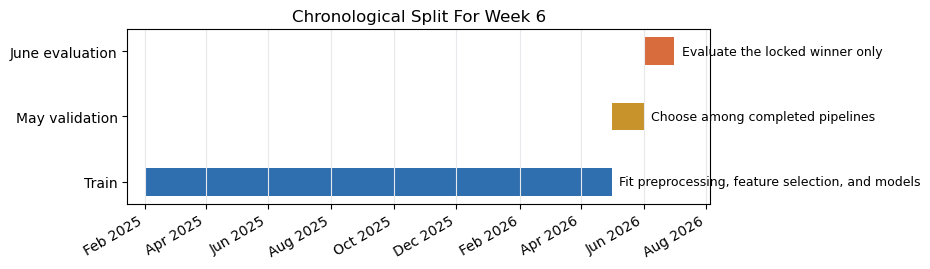

In [8]:

import matplotlib.dates as mdates

split_timeline = pd.DataFrame([
    {"stage": "Train", "start": "2025-02-01", "end": "2026-04-30", "purpose": "Fit preprocessing, feature selection, and models"},
    {"stage": "May validation", "start": "2026-05-01", "end": "2026-05-31", "purpose": "Choose among completed pipelines"},
    {"stage": "June evaluation", "start": "2026-06-01", "end": "2026-06-30", "purpose": "Evaluate the locked winner only"},
]).assign(
    start=lambda frame: pd.to_datetime(frame["start"]),
    end=lambda frame: pd.to_datetime(frame["end"]),
)

fig, ax = plt.subplots(figsize=(9.2, 2.8))
colors = {"Train": "#2F6FB0", "May validation": "#C9932B", "June evaluation": "#D86C3D"}
for row_number, row in split_timeline.iterrows():
    ax.barh(
        row["stage"],
        (row["end"] - row["start"]).days + 1,
        left=row["start"],
        color=colors[row["stage"]],
        height=0.42,
    )
    ax.text(row["end"] + pd.Timedelta(days=8), row["stage"], row["purpose"], va="center", fontsize=9)

ax.set_title("Chronological Split For Week 6")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(axis="x", color="#E6E8EB", linewidth=0.8)
ax.set_ylabel("")
ax.set_xlim(pd.Timestamp("2025-01-15"), pd.Timestamp("2026-08-05"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



### Split Takeaways

- **Train:** all preprocessing, feature selection, and model fitting happen before May.
- **Validation:** May chooses among completed pipelines only.
- **Test:** June evaluates the locked winner and does not change the model.


### Train-Fitted Training Filter

Extreme target and price-per-square-foot limits are learned from training data only.

These limits serve two different purposes:

- **Model fitting:** stabilize training by removing extreme training outliers.
- **Comparable June benchmark:** define the in-range June population using training-derived thresholds.

Full-June metrics are still reported separately for operational robustness.


In [9]:
def fit_training_filter(train_frame):
    price_low, price_high = train_frame[TARGET].quantile([0.005, 0.995])

    train_filtered = train_frame[train_frame[TARGET].between(price_low, price_high)].copy()

    ppsf_low = np.nan
    ppsf_high = np.nan
    if "price_per_sqft_audit" in train_filtered.columns:
        train_ppsf = pd.to_numeric(train_filtered["price_per_sqft_audit"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        train_ppsf = train_ppsf.dropna()
        if len(train_ppsf):
            ppsf_low, ppsf_high = train_ppsf.quantile([0.005, 0.995])
            values = pd.to_numeric(train_filtered["price_per_sqft_audit"], errors="coerce").replace([np.inf, -np.inf], np.nan)
            train_filtered = train_filtered[values.isna() | values.between(ppsf_low, ppsf_high)].copy()

    return train_filtered.reset_index(drop=True), {
        "closeprice_p005_train": float(price_low),
        "closeprice_p995_train": float(price_high),
        "price_per_sqft_p005_train": float(ppsf_low) if pd.notna(ppsf_low) else np.nan,
        "price_per_sqft_p995_train": float(ppsf_high) if pd.notna(ppsf_high) else np.nan,
    }


train, outlier_params = fit_training_filter(train)

split_summary["rows_after_training_filter"] = [len(train), len(validation), np.nan]
print("Train-fitted ClosePrice filter:", round(outlier_params["closeprice_p005_train"], 0), "to", round(outlier_params["closeprice_p995_train"], 0))
print("Train-fitted price/sqft filter:", round(outlier_params["price_per_sqft_p005_train"], 2), "to", round(outlier_params["price_per_sqft_p995_train"], 2))
split_summary

Train-fitted ClosePrice filter: 188420.0 to 8554609.0
Train-fitted price/sqft filter: 162.5 to 2092.38


,split,rows_before_filter,rows_with_closeprice,start_month,end_month,rows_after_training_filter
0,train,154769,154769,2025-02,2026-04,151691.0
1,validation,12002,12002,2026-05,2026-05,12002.0
2,test,12851,12851,2026-06,2026-06,NaN


### Technical Build: Metrics And Preprocessing

The preprocessor is fit inside each candidate pipeline using train only. Validation and test receive frozen train-fitted transformations.


In [10]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    keep = y_true != 0
    return float(np.mean(np.abs((y_true[keep] - y_pred[keep]) / y_true[keep])))


def mdape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    keep = y_true != 0
    return float(np.median(np.abs((y_true[keep] - y_pred[keep]) / y_true[keep])))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def evaluate_predictions(y_true, y_pred, prefix):
    return {
        f"{prefix}_R2": float(r2_score(y_true, y_pred)),
        f"{prefix}_MAE": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_RMSE": rmse(y_true, y_pred),
        f"{prefix}_MAPE": mape(y_true, y_pred),
        f"{prefix}_MdAPE": mdape(y_true, y_pred),
    }


def build_train_validation_matrices(train_frame, validation_frame, spec):
    preprocessor = CRMLSFeaturePreprocessor(spec, missingness_limit=MISSINGNESS_LIMIT)
    x_train = preprocessor.fit_transform(train_frame)
    x_validation = preprocessor.transform(validation_frame)

    if x_train.shape[1] == 0:
        raise ValueError("No features available after preprocessing.")

    return x_train, x_validation, preprocessor, preprocessor.get_preprocess_params()


print("Defined metrics and train-fitted raw-data preprocessor.")

Defined metrics and train-fitted raw-data preprocessor.


### Technical Build: Train-Only Feature Selectors

These selectors are fit on `x_train` only. They create locked candidate pipelines. Validation does not select raw variables.


In [11]:
def correlation_filter_features(x_train, threshold=0.95):
    corr = x_train.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    dropped = [col for col in upper.columns if any(upper[col] > threshold)]
    selected = [col for col in x_train.columns if col not in dropped]
    return selected, dropped


def lasso_select_features(x_train, y_train, random_state=RANDOM_STATE):
    y_values = np.asarray(y_train, dtype=float)
    y_scaled = (y_values - y_values.mean()) / (y_values.std() or 1.0)
    model = LassoCV(
        alphas=np.logspace(-3, 3, 30),
        cv=TimeSeriesSplit(n_splits=3),
        max_iter=5000,
        n_jobs=-1,
        random_state=random_state,
    )
    model.fit(x_train, y_scaled)
    coefficient_abs = pd.Series(np.abs(model.coef_), index=x_train.columns)
    selected = coefficient_abs[coefficient_abs > 1e-8].sort_values(ascending=False).index.tolist()
    if len(selected) < 10:
        selected = coefficient_abs.sort_values(ascending=False).head(min(30, len(coefficient_abs))).index.tolist()
    dropped = [col for col in x_train.columns if col not in selected]
    return selected, dropped, {"lasso_alpha": float(model.alpha_)}


def rf_importance_select_features(x_train, y_train, top_n=35, random_state=RANDOM_STATE):
    model = RandomForestRegressor(
        n_estimators=40,
        max_depth=18,
        min_samples_leaf=20,
        max_features=0.6,
        n_jobs=-1,
        random_state=random_state,
    )
    model.fit(x_train, y_train)
    importances = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
    selected = importances.head(min(top_n, len(importances))).index.tolist()
    dropped = [col for col in x_train.columns if col not in selected]
    return selected, dropped, {"rf_selector_top_importance": importances.head(15).to_dict()}


print("Defined train-only feature selectors with time-aware LassoCV.")

Defined train-only feature selectors with time-aware LassoCV.


### Technical Build: Candidate Pipeline Builder

Each candidate below is a complete train-fitted pipeline: preprocessing, optional feature selection, and model training all happen before validation scoring.


In [12]:
def make_estimator(model_type):
    if model_type == "LinearRegression":
        return LinearRegression()
    if model_type == "RidgeCV":
        return TransformedTargetRegressor(
            regressor=RidgeCV(alphas=np.logspace(-2, 6, 25), cv=TimeSeriesSplit(n_splits=3)),
            transformer=StandardScaler(),
        )
    if model_type == "LassoCV":
        return TransformedTargetRegressor(
            regressor=LassoCV(
                alphas=np.logspace(-3, 3, 30),
                cv=TimeSeriesSplit(n_splits=3),
                max_iter=5000,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
            transformer=StandardScaler(),
        )
    if model_type == "DecisionTree":
        return DecisionTreeRegressor(max_depth=20, min_samples_leaf=50, random_state=RANDOM_STATE)
    if model_type == "RandomForest":
        return RandomForestRegressor(
            n_estimators=50,
            max_depth=22,
            min_samples_leaf=10,
            max_features=0.6,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown model type: {model_type}")

print("Defined model estimators.")


Defined model estimators.


In [13]:
CANDIDATE_PIPELINES = [
    {"pipeline": "X5_no_school + Random Forest", "feature_spec": "X5_no_school", "selector": "none", "model_type": "RandomForest"},
    {"pipeline": "X5_fixed + Linear Regression", "feature_spec": "X5_fixed", "selector": "none", "model_type": "LinearRegression"},
    {"pipeline": "X5_fixed + Ridge", "feature_spec": "X5_fixed", "selector": "none", "model_type": "RidgeCV"},
    {"pipeline": "X5_fixed + Lasso", "feature_spec": "X5_fixed", "selector": "none", "model_type": "LassoCV"},
    {"pipeline": "X5_fixed + Decision Tree", "feature_spec": "X5_fixed", "selector": "none", "model_type": "DecisionTree"},
    {"pipeline": "X5_fixed + Random Forest", "feature_spec": "X5_fixed", "selector": "none", "model_type": "RandomForest"},
    {"pipeline": "X6_no_school + Random Forest", "feature_spec": "X6_engineered_no_school", "selector": "none", "model_type": "RandomForest"},
    {"pipeline": "X6_full + Random Forest", "feature_spec": "X6_engineered", "selector": "none", "model_type": "RandomForest"},
    {"pipeline": "Correlation-filtered X6 + Ridge", "feature_spec": "X6_engineered", "selector": "correlation_filter", "model_type": "RidgeCV"},
    {"pipeline": "Lasso-selected X6 + Linear Regression", "feature_spec": "X6_engineered", "selector": "lasso_selection", "model_type": "LinearRegression"},
    {"pipeline": "Lasso-selected X6 + Ridge", "feature_spec": "X6_engineered", "selector": "lasso_selection", "model_type": "RidgeCV"},
    {"pipeline": "RF-importance-selected X6 + Random Forest", "feature_spec": "X6_engineered", "selector": "rf_importance", "model_type": "RandomForest"},
    {"pipeline": "Combined-selected X6 + Random Forest", "feature_spec": "X6_engineered", "selector": "combined_lasso_rf", "model_type": "RandomForest"},
]

print("Defined candidate pipeline list:", len(CANDIDATE_PIPELINES), "pipelines.")


Defined candidate pipeline list: 13 pipelines.


In [14]:
def select_features_for_candidate(candidate, x_train_full, y_train):
    selector = candidate["selector"]
    selector_params = {}

    if selector == "none":
        selected_features = x_train_full.columns.tolist()
        removed_features = []
    elif selector == "correlation_filter":
        selected_features, removed_features = correlation_filter_features(x_train_full)
    elif selector == "lasso_selection":
        selected_features, removed_features, selector_params = lasso_select_features(x_train_full, y_train)
    elif selector == "rf_importance":
        selected_features, removed_features, selector_params = rf_importance_select_features(x_train_full, y_train)
    elif selector == "combined_lasso_rf":
        lasso_features, _, lasso_params = lasso_select_features(x_train_full, y_train)
        rf_features, _, rf_params = rf_importance_select_features(x_train_full, y_train)
        selected_features = sorted(set(lasso_features).union(rf_features))
        removed_features = [col for col in x_train_full.columns if col not in selected_features]
        selector_params = {
            "lasso_alpha": lasso_params.get("lasso_alpha"),
            "combined_rule": "union_lasso_and_rf_top_features",
        }
    else:
        raise ValueError(f"Unknown selector: {selector}")

    return selected_features, removed_features, selector_params


print("Defined candidate feature-selection dispatcher.")

Defined candidate feature-selection dispatcher.


In [15]:
def package_raw_prediction_pipeline(preprocessor, selected_features, model, x_train_full):
    selector_step = ColumnSelector(selected_features).fit(x_train_full)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("selector", selector_step),
        ("model", model),
    ])


def build_candidate_result(candidate, spec, train_frame, validation_frame, selected_features, removed_features, y_train, y_validation, train_pred, validation_pred, x_train_full):
    result = {
        "pipeline": candidate["pipeline"],
        "feature_spec": candidate["feature_spec"],
        "selector": candidate["selector"],
        "model_type": candidate["model_type"],
        "raw_feature_count": len(spec["numeric"] + spec["categorical"] + spec["binary"]),
        "transformed_feature_count_before_selection": int(x_train_full.shape[1]),
        "selected_feature_count": len(selected_features),
        "removed_feature_count": len(removed_features),
        "train_rows": len(train_frame),
        "validation_rows": len(validation_frame),
        **evaluate_predictions(y_train, train_pred, "train"),
        **evaluate_predictions(y_validation, validation_pred, "validation"),
    }
    result["train_minus_validation_R2"] = result["train_R2"] - result["validation_R2"]
    result["validation_minus_train_MdAPE"] = result["validation_MdAPE"] - result["train_MdAPE"]
    return result


print("Defined candidate packaging and metric helpers.")

Defined candidate packaging and metric helpers.


In [16]:
def fit_candidate_pipeline(candidate, train_frame, validation_frame):
    spec = FEATURE_SPECS[candidate["feature_spec"]]
    x_train_full, x_validation_full, preprocessor, preprocess_params = build_train_validation_matrices(
        train_frame,
        validation_frame,
        spec,
    )
    y_train = train_frame[TARGET].astype(float)
    y_validation = validation_frame[TARGET].astype(float)

    selected_features, removed_features, selector_params = select_features_for_candidate(
        candidate,
        x_train_full,
        y_train,
    )
    x_train = x_train_full[selected_features]
    x_validation = x_validation_full[selected_features]

    model = make_estimator(candidate["model_type"])
    model.fit(x_train, y_train)
    train_pred = model.predict(x_train)
    validation_pred = model.predict(x_validation)

    result = build_candidate_result(
        candidate,
        spec,
        train_frame,
        validation_frame,
        selected_features,
        removed_features,
        y_train,
        y_validation,
        train_pred,
        validation_pred,
        x_train_full,
    )

    fitted = {
        "candidate": candidate,
        "model": model,
        "raw_prediction_pipeline": package_raw_prediction_pipeline(preprocessor, selected_features, model, x_train_full),
        "preprocessor": preprocessor,
        "selected_features": selected_features,
        "removed_features": removed_features,
        "preprocess_params": preprocess_params,
        "selector_params": selector_params,
        "x_train": x_train,
        "x_validation": x_validation,
        "y_train": y_train,
        "y_validation": y_validation,
        "train_frame": train_frame,
        "validation_frame": validation_frame,
        "result": result,
    }
    return result, fitted


print("Defined candidate pipeline builder:", len(CANDIDATE_PIPELINES), "pipelines.")

Defined candidate pipeline builder: 13 pipelines.


## 3. May Validation Decision

This is the only phase where feature selection is fitted. The validation set is not used to create or modify feature lists.


In [17]:
fitted_pipelines = {}
candidate_results = []

for candidate in CANDIDATE_PIPELINES:
    print("Training candidate pipeline:", candidate["pipeline"])
    result, fitted = fit_candidate_pipeline(candidate, train, validation)
    candidate_results.append(result)
    fitted_pipelines[candidate["pipeline"]] = fitted

validation_results = pd.DataFrame(candidate_results).sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
).reset_index(drop=True)

validation_results.to_csv(OUTPUT_DIR / "week6_candidate_pipeline_validation_metrics.csv", index=False)
candidate_summary = validation_results[[
    "pipeline", "model_type", "selected_feature_count", "validation_MdAPE"
]].head(8).copy()
candidate_summary["validation_MdAPE_pct"] = candidate_summary["validation_MdAPE"].mul(100).round(2)
print("Candidate validation metrics saved to:", OUTPUT_DIR / "week6_candidate_pipeline_validation_metrics.csv")
print("Best validation pipeline:", candidate_summary.iloc[0]["pipeline"])

Training candidate pipeline: X5_no_school + Random Forest


Training candidate pipeline: X5_fixed + Linear Regression


Training candidate pipeline: X5_fixed + Ridge


Training candidate pipeline: X5_fixed + Lasso


Training candidate pipeline: X5_fixed + Decision Tree


...

Training candidate pipeline: Lasso-selected X6 + Linear Regression


Training candidate pipeline: Lasso-selected X6 + Ridge


Training candidate pipeline: RF-importance-selected X6 + Random Forest


Training candidate pipeline: Combined-selected X6 + Random Forest


Candidate validation metrics saved to: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering/week6_candidate_pipeline_validation_metrics.csv
Best validation pipeline: X5_fixed + Random Forest


### Candidate Training Result Summary

- **Winner:** `X5_fixed + Random Forest` has the best May validation MdAPE.
- **X6 result:** engineered features do not materially improve the Random Forest benchmark.
- **Selector result:** X6 selectors reduce feature count, but do not improve validation error enough to replace X5.
- **School layer:** no-school controls perform slightly worse, so school fields stay in the current benchmark pending rolling validation.
- **Model family:** tree models outperform linear and regularized linear models, confirming nonlinear pricing patterns.


### Validation MdAPE Ranking

The figure below is the main decision view for candidate selection. Lower MdAPE is better. The full candidate table is saved for audit, but the notebook should be read from the chart first.

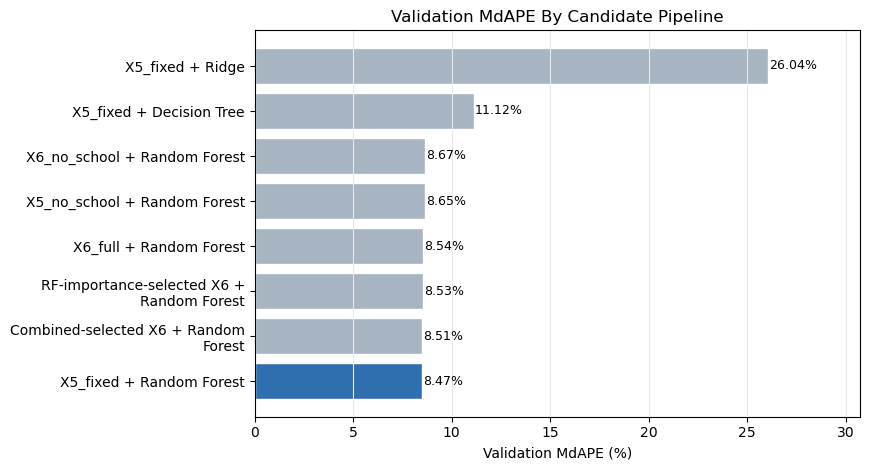

In [18]:
validation_plot = validation_results.sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
).head(8).copy()
validation_plot["validation_MdAPE_pct"] = validation_plot["validation_MdAPE"] * 100
best_pipeline_for_plot = validation_plot.iloc[0]["pipeline"]

fig, ax = plt.subplots(figsize=(8.8, 4.8))
y_pos = np.arange(len(validation_plot))[::-1]
colors = ["#2F6FB0" if p == best_pipeline_for_plot else "#A7B4C2" for p in validation_plot["pipeline"]]
labels = [textwrap.fill(p.replace(" + ", " + "), 30) for p in validation_plot["pipeline"]]

ax.barh(y_pos, validation_plot["validation_MdAPE_pct"][::-1], color=colors[::-1], edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels[::-1])
ax.set_xlabel("Validation MdAPE (%)")
ax.set_title("Validation MdAPE By Candidate Pipeline")
ax.grid(axis="x", color="#E6E8EB", linewidth=0.8)

for y_value, mdape_value in zip(y_pos, validation_plot["validation_MdAPE_pct"][::-1]):
    ax.text(mdape_value + 0.05, y_value, f"{mdape_value:.2f}%", va="center", fontsize=9)

ax.set_xlim(0, validation_plot["validation_MdAPE_pct"].max() * 1.18)
plt.tight_layout()
plt.show()


### Validation Chart Takeaways

- **Selected pipeline:** `X5_fixed + Random Forest` has the lowest May validation MdAPE.
- **X6 does not win:** the full and selected X6 pipelines are close, but not better enough to replace X5.
- **Decision rule:** June is not used here; the winner is locked from May validation only.


### Validation Selection Rule

May 2026 validation compares pre-defined completed pipelines. It does not refit selectors, adjust feature lists, or inspect June results.

| Pipeline group | Feature set or selection strategy | Model candidates |
| --- | --- | --- |
| School-layer control | X5 without school-district fields | Random Forest |
| Baseline | `X5_full_non_leaky` fixed features, including school layer | Linear Regression, Ridge, Lasso, Decision Tree, Random Forest |
| Feature-engineering control | X6 full engineered features without selector | Random Forest |
| School-layer + engineering control | X6 engineered features without school layer | Random Forest |
| Pipeline A | Correlation-filtered X6 features fitted on train | Ridge |
| Pipeline B | Lasso-selected X6 features fitted on train | Linear Regression, Ridge |
| Pipeline C | RF-importance-selected X6 features fitted on train | Random Forest |
| Pipeline D | Combined Lasso + RF selected X6 features fitted on train | Random Forest |

Selection rule: lowest validation `MdAPE`, then `MAPE`, then `R2`.


In [19]:
selected_pipeline_name = validation_results.loc[0, "pipeline"]
selected_fit = fitted_pipelines[selected_pipeline_name]

print("Selected pipeline:", selected_pipeline_name)
print("Selector:", selected_fit["candidate"]["selector"])
print("Model:", selected_fit["candidate"]["model_type"])
print("Selected features:", len(selected_fit["selected_features"]))
print("Removed features:", len(selected_fit["removed_features"]))
print("Validation R2:", round(validation_results.loc[0, "validation_R2"], 4))
print("Validation MAPE:", round(validation_results.loc[0, "validation_MAPE"], 4))
print("Validation MdAPE:", round(validation_results.loc[0, "validation_MdAPE"], 4))

print("Locked pipeline selected on May validation only:", selected_pipeline_name)

Selected pipeline: X5_fixed + Random Forest
Selector: none
Model: RandomForest
Selected features: 70
Removed features: 0
Validation R2: 0.6767
Validation MAPE: 0.1485
Validation MdAPE: 0.0847
Locked pipeline selected on May validation only: X5_fixed + Random Forest


- The selection rule prioritizes lowest validation MdAPE, then MAPE, then R2.
- `X5_fixed + Random Forest` is selected because it has the best validation MdAPE.
- This means the Week 6 selected alternatives were tested, but did not justify replacing the Week 5 RF structure.


## 4. Why X5 Was Retained

This section explains why the validation stage selected `X5_fixed + Random Forest`.

Each comparison changes only one design choice at a time:

- **School layer:** compare the same RF model with and without school-district fields.
- **Engineered features:** compare X5 RF against X6 full RF before feature selection.
- **Feature selection:** compare X6 full RF against selected-X6 RF.

All comparisons use May validation only. June is not used here.


In [20]:
def get_validation_row(pipeline_name):
    rows = validation_results[validation_results["pipeline"].eq(pipeline_name)]
    if len(rows) == 0:
        return None
    return rows.iloc[0]


selected_x6_rf = (
    validation_results[
        validation_results["feature_spec"].eq("X6_engineered")
        & validation_results["model_type"].eq("RandomForest")
        & validation_results["selector"].ne("none")
    ]
    .sort_values(["validation_MdAPE", "validation_MAPE", "validation_R2"], ascending=[True, True, False])
)
selected_x6_rf_name = selected_x6_rf.iloc[0]["pipeline"] if len(selected_x6_rf) else None

comparison_pairs = [
    {
        "comparison": "School layer effect within X5 RF",
        "baseline_pipeline": "X5_no_school + Random Forest",
        "challenger_pipeline": "X5_fixed + Random Forest",
        "question_answered": "Does adding the school-district layer improve the Week 5 RF feature set?",
    },
    {
        "comparison": "School layer effect within X6 RF",
        "baseline_pipeline": "X6_no_school + Random Forest",
        "challenger_pipeline": "X6_full + Random Forest",
        "question_answered": "Does adding the school-district layer improve the engineered RF feature set?",
    },
    {
        "comparison": "Engineered feature effect without selector",
        "baseline_pipeline": "X5_fixed + Random Forest",
        "challenger_pipeline": "X6_full + Random Forest",
        "question_answered": "Do the engineered features improve RF before any feature selector removes variables?",
    },
    {
        "comparison": "Selector effect on X6 RF",
        "baseline_pipeline": "X6_full + Random Forest",
        "challenger_pipeline": selected_x6_rf_name,
        "question_answered": "Does train-only feature selection improve the engineered RF feature pool?",
    },
]

print("Defined controlled comparison pairs.")


Defined controlled comparison pairs.


In [21]:
controlled_rows = []
for item in comparison_pairs:
    baseline = get_validation_row(item["baseline_pipeline"])
    challenger = get_validation_row(item["challenger_pipeline"]) if item["challenger_pipeline"] else None
    if baseline is None or challenger is None:
        continue

    mdape_delta = challenger["validation_MdAPE"] - baseline["validation_MdAPE"]
    mape_delta = challenger["validation_MAPE"] - baseline["validation_MAPE"]
    r2_delta = challenger["validation_R2"] - baseline["validation_R2"]
    if mdape_delta < -0.001:
        decision = "improved validation MdAPE"
    elif mdape_delta > 0.001:
        decision = "worse validation MdAPE"
    else:
        decision = "no material MdAPE change"

    controlled_rows.append({
        **item,
        "baseline_validation_R2": baseline["validation_R2"],
        "challenger_validation_R2": challenger["validation_R2"],
        "delta_R2": r2_delta,
        "baseline_validation_MAPE": baseline["validation_MAPE"],
        "challenger_validation_MAPE": challenger["validation_MAPE"],
        "delta_MAPE": mape_delta,
        "baseline_validation_MdAPE": baseline["validation_MdAPE"],
        "challenger_validation_MdAPE": challenger["validation_MdAPE"],
        "delta_MdAPE": mdape_delta,
        "validation_decision": decision,
    })

controlled_feature_set_comparison = pd.DataFrame(controlled_rows)
controlled_feature_set_comparison.to_csv(
    OUTPUT_DIR / "week6_controlled_feature_set_comparison.csv",
    index=False,
)

controlled_summary = controlled_feature_set_comparison[[
    "comparison", "delta_MdAPE", "validation_decision"
]].copy()
controlled_summary["delta_MdAPE_pp"] = controlled_summary["delta_MdAPE"].mul(100).round(2)
print("Controlled comparison saved to:", OUTPUT_DIR / "week6_controlled_feature_set_comparison.csv")
display(controlled_summary[["comparison", "delta_MdAPE_pp", "validation_decision"]])

Controlled comparison saved to: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering/week6_controlled_feature_set_comparison.csv


,comparison,delta_MdAPE_pp,validation_decision
0,School layer effect within X5 RF,-0.18,improved validation MdAPE
1,School layer effect within X6 RF,-0.13,improved validation MdAPE
2,Engineered feature effect without selector,0.06,no material MdAPE change
3,Selector effect on X6 RF,-0.02,no material MdAPE change


### Controlled Comparison Interpretation

- **School layer:** school fields show a small May-validation benefit in both X5 and X6.
- **Engineered features:** X6 full does not outperform X5 full, so added engineered features do not justify replacing X5.
- **Feature selection:** RF selection reduces feature count, but does not improve validation MdAPE enough to replace X6 full.
- **Decision:** keep `X5_fixed + Random Forest` as the locked Week 6 model.


### Controlled Feature-Set Effect Chart

This figure answers three separate questions: whether school fields help, whether X6 engineered features help, and whether feature selection helps.

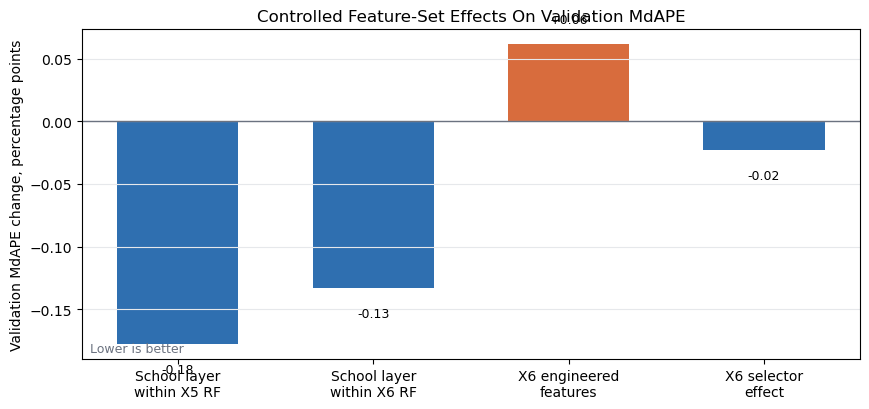

In [22]:
controlled_plot = controlled_feature_set_comparison.copy()
label_map = {
    "School layer effect within X5 RF": "School layer\nwithin X5 RF",
    "School layer effect within X6 RF": "School layer\nwithin X6 RF",
    "Engineered feature effect without selector": "X6 engineered\nfeatures",
    "Selector effect on X6 RF": "X6 selector\neffect",
}
controlled_plot["label"] = controlled_plot["comparison"].map(label_map)
controlled_plot["delta_mdape_pp"] = controlled_plot["delta_MdAPE"] * 100

fig, ax = plt.subplots(figsize=(8.8, 4.2))
x_pos = np.arange(len(controlled_plot))
colors = ["#2F6FB0" if value < 0 else "#D86C3D" for value in controlled_plot["delta_mdape_pp"]]

ax.axhline(0, color="#6B7280", linewidth=1)
ax.bar(x_pos, controlled_plot["delta_mdape_pp"], color=colors, width=0.62)
ax.set_xticks(x_pos)
ax.set_xticklabels(controlled_plot["label"])
ax.set_ylabel("Validation MdAPE change, percentage points")
ax.set_title("Controlled Feature-Set Effects On Validation MdAPE")
ax.grid(axis="y", color="#E6E8EB", linewidth=0.8)

for x_value, delta in zip(x_pos, controlled_plot["delta_mdape_pp"]):
    vertical_align = "bottom" if delta >= 0 else "top"
    offset = 0.015 if delta >= 0 else -0.015
    ax.text(x_value, delta + offset, f"{delta:+.2f}", ha="center", va=vertical_align, fontsize=9)

ax.text(0.01, 0.02, "Lower is better", transform=ax.transAxes, color="#6B7280", fontsize=9)
plt.tight_layout()
plt.show()


### Controlled Comparison Takeaways

- **School layer:** retained in the current benchmark because it shows a small validation benefit.
- **Caveat:** the benefit is only about 0.13-0.18 percentage points and needs rolling-month confirmation.
- **X6 features/selectors:** tested, but not strong enough to replace X5 RF.


## 5. June Results

The selected pipeline is locked before this section. June is used only for evaluation.

Two June views are reported:

- **June in-range:** main comparable Week 5 vs Week 6 benchmark, using training-defined target limits.
- **Full June:** stricter operational robustness check on all eligible June SFR sales.


In [23]:
test = test_raw[test_raw[TARGET].notna()].sort_values("CloseDate").reset_index(drop=True).copy()
if len(test) == 0:
    raise ValueError("June test set is empty.")

model = selected_fit["model"]
raw_prediction_pipeline = selected_fit["raw_prediction_pipeline"]
y_train = selected_fit["y_train"]
y_validation = selected_fit["y_validation"]
y_test = test[TARGET].astype(float)

train_pred = model.predict(selected_fit["x_train"])
validation_pred = model.predict(selected_fit["x_validation"])
test_pred = raw_prediction_pipeline.predict(test)

selected_metrics = {
    "pipeline": selected_pipeline_name,
    "feature_spec": selected_fit["candidate"]["feature_spec"],
    "selector": selected_fit["candidate"]["selector"],
    "model_type": selected_fit["candidate"]["model_type"],
    "selected_feature_count": len(selected_fit["selected_features"]),
    "removed_feature_count": len(selected_fit["removed_features"]),
    "test_rows": len(test),
    **evaluate_predictions(y_train, train_pred, "train"),
    **evaluate_predictions(y_validation, validation_pred, "validation"),
    **evaluate_predictions(y_test, test_pred, "test"),
}
selected_metrics["train_minus_validation_R2"] = selected_metrics["train_R2"] - selected_metrics["validation_R2"]
selected_metrics["validation_minus_test_R2"] = selected_metrics["validation_R2"] - selected_metrics["test_R2"]
selected_metrics["test_minus_validation_MdAPE"] = selected_metrics["test_MdAPE"] - selected_metrics["validation_MdAPE"]

final_test_metrics = pd.DataFrame([selected_metrics])
final_test_metrics.to_csv(OUTPUT_DIR / "week6_final_locked_pipeline_test_metrics.csv", index=False)

def in_training_range_population(frame, params):
    filtered = frame[
        frame[TARGET].between(params["closeprice_p005_train"], params["closeprice_p995_train"])
    ].copy()
    ppsf_low = params.get("price_per_sqft_p005_train", np.nan)
    ppsf_high = params.get("price_per_sqft_p995_train", np.nan)
    if "price_per_sqft_audit" in filtered.columns and pd.notna(ppsf_low) and pd.notna(ppsf_high):
        values = pd.to_numeric(filtered["price_per_sqft_audit"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        filtered = filtered[values.isna() | values.between(ppsf_low, ppsf_high)].copy()
    return filtered


validation_in_range = in_training_range_population(validation, outlier_params)
test_in_range = in_training_range_population(test, outlier_params)
sensitivity_rows = []
for split_name, frame in [("validation_in_training_range", validation_in_range), ("june_in_training_range", test_in_range)]:
    if len(frame):
        prediction = raw_prediction_pipeline.predict(frame)
        sensitivity_rows.append({
            "population": split_name,
            "rows": len(frame),
            **evaluate_predictions(frame[TARGET].astype(float), prediction, "metric"),
        })

secondary_sensitivity_metrics = pd.DataFrame(sensitivity_rows)
secondary_sensitivity_metrics.to_csv(OUTPUT_DIR / "week6_secondary_in_range_metrics.csv", index=False)

june_in_range_row = secondary_sensitivity_metrics[
    secondary_sensitivity_metrics["population"].eq("june_in_training_range")
].iloc[0]

june_summary = pd.DataFrame([
    {
        "evaluation_view": "Comparable benchmark",
        "population": "June in-range: training-defined target range",
        "rows": int(june_in_range_row["rows"]),
        "R2": float(june_in_range_row["metric_R2"]),
        "MAPE_pct": float(june_in_range_row["metric_MAPE"]) * 100,
        "MdAPE_pct": float(june_in_range_row["metric_MdAPE"]) * 100,
    },
    {
        "evaluation_view": "Operational robustness",
        "population": "Full June: all eligible SFR sales",
        "rows": selected_metrics["test_rows"],
        "R2": selected_metrics["test_R2"],
        "MAPE_pct": selected_metrics["test_MAPE"] * 100,
        "MdAPE_pct": selected_metrics["test_MdAPE"] * 100,
    },
])
display(june_summary.round({"R2": 4, "MAPE_pct": 2, "MdAPE_pct": 2}))

,evaluation_view,population,rows,R2,MAPE_pct,MdAPE_pct
0,Comparable benchmark,June in-range: training-defined target range,12566,0.877,12.90,8.29
1,Operational robustness,Full June: all eligible SFR sales,12851,0.595,14.95,8.55


### June Evaluation Interpretation

- **Comparable benchmark:** June in-range is the main Week 5 vs Week 6 comparison because it uses training-defined target limits.
- **Operational robustness:** Full June keeps all eligible June SFR sales and shows how performance changes when extreme transactions remain included.
- **Model discipline:** June results are not used to select, revise, or tune the model.


### June Evaluation Visuals

The comparable benchmark and full-June robustness view are shown separately because they use different June populations.


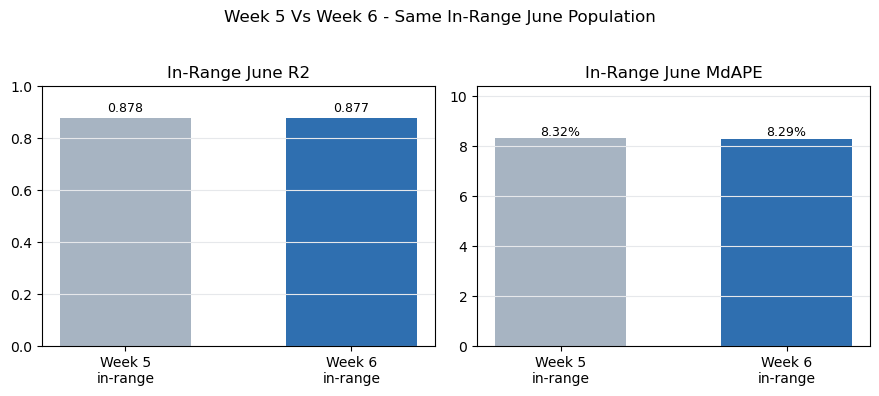

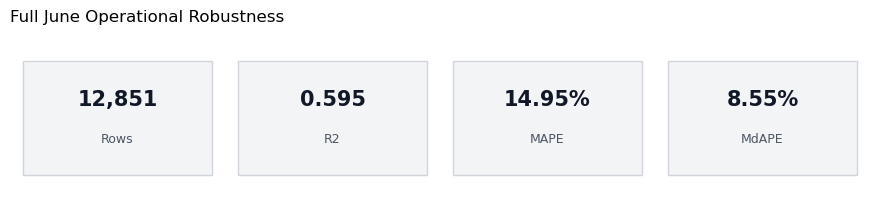

In [24]:
week5_for_plot = pd.read_csv(WEEK5_METRICS_PATH) if WEEK5_METRICS_PATH.exists() else pd.DataFrame()
if {"model", "R2", "MAPE", "MdAPE"}.issubset(week5_for_plot.columns):
    week5_for_plot = week5_for_plot[
        week5_for_plot["model"].astype(str).str.contains("Selected model", na=False)
    ].copy()

june_in_range_metrics = secondary_sensitivity_metrics[
    secondary_sensitivity_metrics["population"].eq("june_in_training_range")
]

benchmark_rows = []
if len(week5_for_plot):
    week5_row = week5_for_plot.iloc[0]
    benchmark_rows.append({
        "label": "Week 5\nin-range",
        "R2": float(week5_row["R2"]),
        "MAPE": float(week5_row["MAPE"]),
        "MdAPE": float(week5_row["MdAPE"]),
    })
if len(june_in_range_metrics):
    in_range_row = june_in_range_metrics.iloc[0]
    benchmark_rows.append({
        "label": "Week 6\nin-range",
        "R2": float(in_range_row["metric_R2"]),
        "MAPE": float(in_range_row["metric_MAPE"]),
        "MdAPE": float(in_range_row["metric_MdAPE"]),
    })

benchmark_plot = pd.DataFrame(benchmark_rows)
benchmark_plot["MdAPE_pct"] = benchmark_plot["MdAPE"] * 100
benchmark_plot["MAPE_pct"] = benchmark_plot["MAPE"] * 100

fig, axes = plt.subplots(1, 2, figsize=(8.9, 3.8))
colors = ["#A7B4C2", "#2F6FB0"][:len(benchmark_plot)]

axes[0].bar(benchmark_plot["label"], benchmark_plot["R2"], color=colors, width=0.58)
axes[0].set_title("In-Range June R2")
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", color="#E6E8EB", linewidth=0.8)
for idx, metric_value in enumerate(benchmark_plot["R2"]):
    axes[0].text(idx, metric_value + 0.025, f"{metric_value:.3f}", ha="center", fontsize=9)

axes[1].bar(benchmark_plot["label"], benchmark_plot["MdAPE_pct"], color=colors, width=0.58)
axes[1].set_title("In-Range June MdAPE")
axes[1].set_ylim(0, benchmark_plot["MdAPE_pct"].max() * 1.25)
axes[1].grid(axis="y", color="#E6E8EB", linewidth=0.8)
for idx, metric_value in enumerate(benchmark_plot["MdAPE_pct"]):
    axes[1].text(idx, metric_value + 0.12, f"{metric_value:.2f}%", ha="center", fontsize=9)

fig.suptitle("Week 5 Vs Week 6 - Same In-Range June Population", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

full_june_kpis = [
    ("Rows", f"{selected_metrics['test_rows']:,}"),
    ("R2", f"{selected_metrics['test_R2']:.3f}"),
    ("MAPE", f"{selected_metrics['test_MAPE'] * 100:.2f}%"),
    ("MdAPE", f"{selected_metrics['test_MdAPE'] * 100:.2f}%"),
]

fig, ax = plt.subplots(figsize=(8.9, 2.2))
ax.axis("off")
for idx, (label, value) in enumerate(full_june_kpis):
    x_left = idx / len(full_june_kpis)
    ax.add_patch(plt.Rectangle((x_left + 0.015, 0.15), 0.22, 0.68, color="#F3F4F6", ec="#D1D5DB"))
    ax.text(x_left + 0.125, 0.60, value, ha="center", va="center", fontsize=15, fontweight="bold", color="#111827")
    ax.text(x_left + 0.125, 0.36, label, ha="center", va="center", fontsize=9, color="#4B5563")
ax.set_title("Full June Operational Robustness", loc="left", fontsize=12, pad=8)
plt.tight_layout()
plt.show()


### June Chart Takeaways

- **Comparable benchmark:** Week 5 and Week 6 should be compared only on the in-range June chart.
- **Performance movement:** Week 6 is effectively unchanged versus Week 5 on the comparable population.
- **Robustness view:** Full June is stricter and shows the impact of extreme June transactions.


### Technical Audit: Feature Selection

This audit reports what the locked train-fitted pipeline kept or removed. If the locked pipeline uses the fixed X5 feature set with no selector, the correct interpretation is that validation rejected the feature-selection alternatives.

In [25]:
feature_status = pd.DataFrame({
    "feature": selected_fit["selected_features"] + selected_fit["removed_features"],
    "status": ["selected"] * len(selected_fit["selected_features"]) + ["removed"] * len(selected_fit["removed_features"]),
    "pipeline": selected_pipeline_name,
    "selector": selected_fit["candidate"]["selector"],
})

new_engineered_tokens = [
    "log_living_area", "log_lot_size_sqft", "bath_per_bedroom", "total_bed_bath",
    "garage_present", "garage_per_bedroom", "fireplaces_per_bedroom",
    "association_fee_present", "tax_per_living_sqft",
]
feature_status["is_new_engineered_feature"] = feature_status["feature"].apply(
    lambda value: any(token in value for token in new_engineered_tokens)
)
feature_status["feature_origin"] = np.where(feature_status["is_new_engineered_feature"], "new_engineered", "existing_x5_or_encoded")

feature_status.to_csv(OUTPUT_DIR / "week6_selected_removed_features.csv", index=False)

selected_engineered = feature_status[
    (feature_status["status"] == "selected") & feature_status["is_new_engineered_feature"]
].copy()
removed_features = feature_status[feature_status["status"] == "removed"].copy()

feature_audit_summary = pd.DataFrame([{
    "selected_pipeline": selected_pipeline_name,
    "selector": selected_fit["candidate"]["selector"],
    "selected_features": len(selected_fit["selected_features"]),
    "removed_features": len(selected_fit["removed_features"]),
    "selected_new_engineered_features": len(selected_engineered),
    "removed_new_engineered_features": int(removed_features["is_new_engineered_feature"].sum()) if len(removed_features) else 0,
    "report_interpretation": (
        "No train-fitted feature selector was adopted. Validation selected the fixed X5 benchmark pipeline."
        if selected_fit["candidate"]["selector"] == "none"
        else "The locked pipeline used train-fitted feature selection. Selected and removed features are listed below."
    ),
}])
feature_audit_summary.to_csv(OUTPUT_DIR / "week6_feature_selection_audit_summary.csv", index=False)

print("Feature audit saved to:", OUTPUT_DIR / "week6_selected_removed_features.csv")
print("Selected transformed features:", len(selected_fit["selected_features"]))
print("Removed transformed features:", len(selected_fit["removed_features"]))
print("Selected new engineered features:", len(selected_engineered))
if selected_fit["candidate"]["selector"] == "none":
    print("No train-fitted selector was adopted; validation selected the fixed X5 benchmark pipeline.")

Feature audit saved to: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering/week6_selected_removed_features.csv
Selected transformed features: 70
Removed transformed features: 0
Selected new engineered features: 0
No train-fitted selector was adopted; validation selected the fixed X5 benchmark pipeline.


### Comparable Benchmark Audit

This section compares Week 5 and Week 6 using the same in-range June benchmark logic. Full June is kept as a separate robustness view and is not used to claim improvement over Week 5.


In [26]:
week5_test_metrics = pd.read_csv(WEEK5_METRICS_PATH) if WEEK5_METRICS_PATH.exists() else pd.DataFrame()

required_week5_metric_columns = {"model", "R2", "MAPE", "MdAPE"}
if required_week5_metric_columns.issubset(week5_test_metrics.columns):
    week5_selected = week5_test_metrics[
        week5_test_metrics["model"].astype(str).str.contains("Selected model", na=False)
    ].copy()
else:
    week5_selected = pd.DataFrame()

old_new_rows = []
if len(week5_selected):
    old = week5_selected.iloc[0]
    old_new_rows.append({
        "comparison": "Week 5 benchmark selected model",
        "population": "legacy in-range June population",
        "pipeline": old["model"],
        "test_R2": old["R2"],
        "test_MAPE": old["MAPE"],
        "test_MdAPE": old["MdAPE"],
        "selected_feature_count": np.nan,
        "directly_comparable_to_week5": True,
    })

if "secondary_sensitivity_metrics" in globals() and len(secondary_sensitivity_metrics):
    june_in_range = secondary_sensitivity_metrics[
        secondary_sensitivity_metrics["population"].eq("june_in_training_range")
    ]
    if len(june_in_range):
        in_range = june_in_range.iloc[0]
        old_new_rows.append({
            "comparison": "Week 6 locked winner comparable benchmark",
            "population": "train-defined in-range June population",
            "pipeline": selected_pipeline_name,
            "test_R2": in_range["metric_R2"],
            "test_MAPE": in_range["metric_MAPE"],
            "test_MdAPE": in_range["metric_MdAPE"],
            "selected_feature_count": selected_metrics["selected_feature_count"],
            "directly_comparable_to_week5": True,
        })

old_new_rows.append({
    "comparison": "Week 6 locked winner full-June robustness",
    "population": "all eligible June SFR transactions",
    "pipeline": selected_pipeline_name,
    "test_R2": selected_metrics["test_R2"],
    "test_MAPE": selected_metrics["test_MAPE"],
    "test_MdAPE": selected_metrics["test_MdAPE"],
    "selected_feature_count": selected_metrics["selected_feature_count"],
    "directly_comparable_to_week5": False,
})

old_vs_new = pd.DataFrame(old_new_rows)
old_vs_new["delta_mdape_vs_week5_selected"] = np.nan
if len(week5_selected):
    week5_mdape = float(old_vs_new.loc[0, "test_MdAPE"])
    comparable_mask = old_vs_new["directly_comparable_to_week5"].eq(True) & (old_vs_new.index != 0)
    old_vs_new.loc[comparable_mask, "delta_mdape_vs_week5_selected"] = (
        old_vs_new.loc[comparable_mask, "test_MdAPE"].astype(float) - week5_mdape
    )

old_vs_new.to_csv(OUTPUT_DIR / "week6_old_vs_new_test_comparison.csv", index=False)
print("Week 5 vs Week 6 comparison saved to:", OUTPUT_DIR / "week6_old_vs_new_test_comparison.csv")


Week 5 vs Week 6 comparison saved to: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering/week6_old_vs_new_test_comparison.csv


### Why Week 5 And Week 6 Differ Slightly

- **Same benchmark specification:** both use `X5_fixed + Random Forest` with the same RF hyperparameters and `random_state`.
- **Main difference:** Week 6 rebuilds preprocessing with cleaner categorical missing-value and unknown-category handling, so the RF receives slightly different transformed inputs.
- **Correct reading:** the comparable June results are effectively unchanged; the small mixed metric movement is not meaningful model improvement.


### Segment Diagnostics

Segment analysis checks where the locked model is weaker after the sale is observed. These bands use realized `ClosePrice`, so they are retrospective diagnostics, not production routing rules.


In [27]:
def make_prediction_frame(frame, prediction, split_name):
    out = frame[["CloseDate", "close_month", TARGET, "City", "PostalCode", "CountyOrParish", "UnifiedSchoolDistrictName"]].copy()
    out["prediction"] = prediction
    out["error"] = out["prediction"] - out[TARGET]
    out["absolute_error"] = out["error"].abs()
    out["absolute_percentage_error"] = out["absolute_error"] / out[TARGET].replace(0, np.nan)
    out["split"] = split_name
    return out


all_predictions = pd.concat([
    make_prediction_frame(selected_fit["train_frame"], train_pred, "train"),
    make_prediction_frame(selected_fit["validation_frame"], validation_pred, "validation"),
    make_prediction_frame(test, test_pred, "test"),
], ignore_index=True)

test_predictions = all_predictions[all_predictions["split"] == "test"].copy()
price_band_edges = selected_fit["train_frame"][TARGET].quantile(np.linspace(0, 1, 6)).to_numpy(copy=True)
price_band_edges[0] = -np.inf
price_band_edges[-1] = np.inf
price_band_edges = np.unique(price_band_edges)
price_segment_labels = ["Q1_lowest", "Q2", "Q3", "Q4", "Q5_highest"][: max(len(price_band_edges) - 1, 0)]
if len(price_band_edges) < 3:
    raise ValueError("Not enough unique training prices to define stable price bands.")

def assign_train_defined_price_segment(values):
    return pd.cut(
        values,
        bins=price_band_edges,
        labels=price_segment_labels,
        include_lowest=True,
    )

test_predictions["price_segment"] = assign_train_defined_price_segment(test_predictions[TARGET])

print("Prepared train, validation, and June prediction frames with train-defined price bands.")


Prepared train, validation, and June prediction frames with train-defined price bands.


In [28]:
segment_errors = (
    test_predictions
    .groupby("price_segment", observed=True)
    .agg(
        rows=(TARGET, "size"),
        median_close_price=(TARGET, "median"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mdape=("absolute_percentage_error", "median"),
        p90_ape=("absolute_percentage_error", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

error_distribution = pd.DataFrame([{
    "pipeline": selected_pipeline_name,
    "mean_error": test_predictions["error"].mean(),
    "median_error": test_predictions["error"].median(),
    "p10_error": test_predictions["error"].quantile(0.10),
    "p90_error": test_predictions["error"].quantile(0.90),
    "p50_ape": test_predictions["absolute_percentage_error"].quantile(0.50),
    "p75_ape": test_predictions["absolute_percentage_error"].quantile(0.75),
    "p90_ape": test_predictions["absolute_percentage_error"].quantile(0.90),
    "p95_ape": test_predictions["absolute_percentage_error"].quantile(0.95),
}])

all_predictions.to_csv(OUTPUT_DIR / "week6_selected_pipeline_predictions.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "week6_selected_pipeline_test_predictions.csv", index=False)
segment_errors.to_csv(OUTPUT_DIR / "week6_selected_pipeline_segment_errors.csv", index=False)
error_distribution.to_csv(OUTPUT_DIR / "week6_selected_pipeline_error_distribution.csv", index=False)

pd.DataFrame({
    "price_segment": price_segment_labels,
    "lower_bound": price_band_edges[:-1],
    "upper_bound": price_band_edges[1:],
    "source": "training ClosePrice quantiles",
}).to_csv(OUTPUT_DIR / "week6_train_defined_price_bands.csv", index=False)

print("Saved Week 6 segment errors and error distribution.")


Saved Week 6 segment errors and error distribution.



### Actual Vs Predicted Check

This diagnostic checks whether June errors are broad model drift or concentrated in unusual transactions.


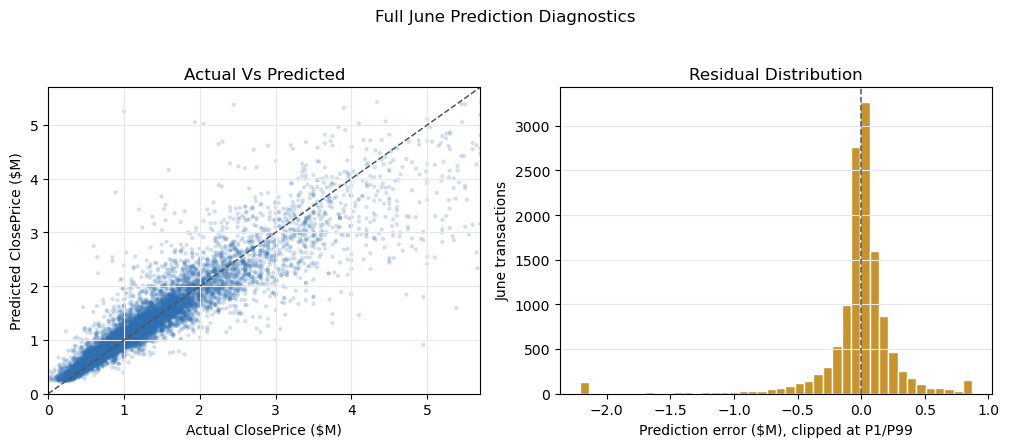

In [29]:

actual_pred_plot = test_predictions.copy()
actual_pred_plot["close_price_millions"] = actual_pred_plot[TARGET] / 1_000_000
actual_pred_plot["prediction_millions"] = actual_pred_plot["prediction"] / 1_000_000
actual_pred_plot["residual_millions"] = actual_pred_plot["error"] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3))
axes[0].scatter(
    actual_pred_plot["close_price_millions"],
    actual_pred_plot["prediction_millions"],
    s=9,
    alpha=0.22,
    color="#2F6FB0",
    edgecolors="none",
)
max_price = np.nanpercentile(
    pd.concat([actual_pred_plot["close_price_millions"], actual_pred_plot["prediction_millions"]]),
    99,
)
axes[0].plot([0, max_price], [0, max_price], color="#4B5563", linewidth=1.1, linestyle="--")
axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual ClosePrice ($M)")
axes[0].set_ylabel("Predicted ClosePrice ($M)")
axes[0].set_title("Actual Vs Predicted")
axes[0].grid(color="#E6E8EB", linewidth=0.8)

residual_clip = actual_pred_plot["residual_millions"].clip(
    lower=actual_pred_plot["residual_millions"].quantile(0.01),
    upper=actual_pred_plot["residual_millions"].quantile(0.99),
)
axes[1].hist(residual_clip, bins=42, color="#C9932B", edgecolor="white")
axes[1].axvline(0, color="#4B5563", linewidth=1.1, linestyle="--")
axes[1].set_xlabel("Prediction error ($M), clipped at P1/P99")
axes[1].set_ylabel("June transactions")
axes[1].set_title("Residual Distribution")
axes[1].grid(axis="y", color="#E6E8EB", linewidth=0.8)

fig.suptitle("Full June Prediction Diagnostics", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()



### Prediction Diagnostic Takeaways

- **Typical homes:** most predictions cluster near the diagonal, supporting use for valuation triage.
- **Tail risk:** residual spread widens for unusual or high-price transactions.
- **Action:** large residual cases should be routed to manual review, not automatic pricing.


In [30]:
if WEEK5_TEST_PREDICTIONS_PATH.exists():
    week5_test_predictions = pd.read_csv(WEEK5_TEST_PREDICTIONS_PATH)
    required_week5_prediction_columns = {TARGET, "absolute_percentage_error", "error"}
    if required_week5_prediction_columns.issubset(week5_test_predictions.columns):
        week5_test_predictions["price_segment"] = assign_train_defined_price_segment(
            pd.to_numeric(week5_test_predictions[TARGET], errors="coerce")
        )
        week5_segment_errors = (
            week5_test_predictions
            .groupby("price_segment", observed=True)
            .agg(
                rows=(TARGET, "size"),
                median_close_price=(TARGET, "median"),
                mae=("error", lambda s: s.abs().mean()),
                mape=("absolute_percentage_error", "mean"),
                mdape=("absolute_percentage_error", "median"),
                p90_ape=("absolute_percentage_error", lambda s: s.quantile(0.90)),
            )
            .reset_index()
        )
    else:
        week5_segment_errors = pd.DataFrame()
elif WEEK5_SEGMENT_PATH.exists():
    week5_segment_errors = pd.read_csv(WEEK5_SEGMENT_PATH)
else:
    week5_segment_errors = pd.DataFrame()

if len(week5_segment_errors):
    segment_comparison = week5_segment_errors.merge(
        segment_errors,
        on="price_segment",
        suffixes=("_week5", "_week6"),
    )
    for metric in ["mae", "mape", "mdape", "p90_ape"]:
        segment_comparison[f"{metric}_delta_week6_minus_week5"] = (
            segment_comparison[f"{metric}_week6"] - segment_comparison[f"{metric}_week5"]
        )
else:
    segment_comparison = pd.DataFrame()

segment_comparison.to_csv(OUTPUT_DIR / "week6_segment_old_vs_new_comparison.csv", index=False)

segment_summary = segment_errors[["price_segment", "rows", "mdape", "p90_ape"]].copy()
segment_summary["MdAPE_pct"] = segment_summary["mdape"].mul(100).round(2)
segment_summary["P90_APE_pct"] = segment_summary["p90_ape"].mul(100).round(2)
display(segment_summary[["price_segment", "rows", "MdAPE_pct", "P90_APE_pct"]])


,price_segment,rows,MdAPE_pct,P90_APE_pct
0,Q1_lowest,2614,8.61,49.58
1,Q2,2361,6.18,23.88
2,Q3,2436,7.22,24.15
3,Q4,2583,9.00,26.34
4,Q5_highest,2857,12.60,36.66


### Price Segment Interpretation

- **Retrospective finding:** performance is weaker in the lowest and highest realized price segments.
- **Middle segments:** Q2 and Q3 have the most stable percentage-error profile.
- **Routing caveat:** production manual-review rules should use prediction-time fields, such as `ListPrice`, predicted price, living area, location, or uncertainty flags.


### Price-Segment Risk Chart

The chart compares median error and tail error by realized price segment defined from training ClosePrice quantiles.


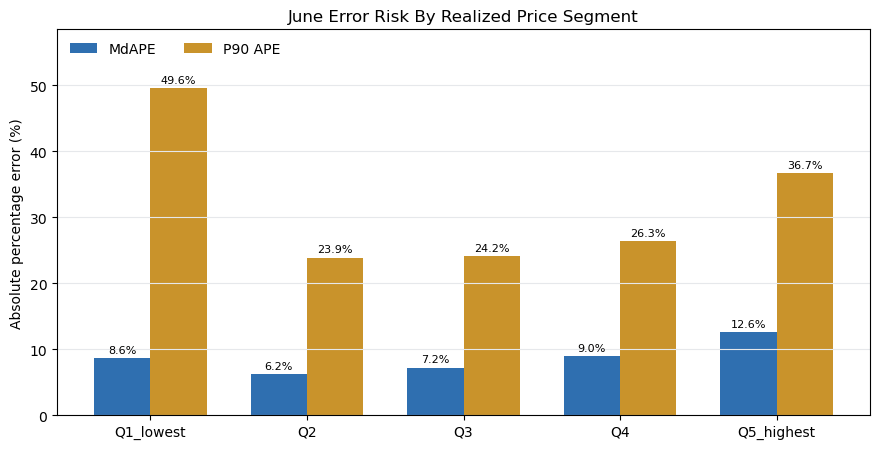

In [31]:
segment_plot = segment_errors.copy()
segment_plot["mdape_pct"] = segment_plot["mdape"] * 100
segment_plot["p90_ape_pct"] = segment_plot["p90_ape"] * 100

fig, ax = plt.subplots(figsize=(8.9, 4.6))
x_pos = np.arange(len(segment_plot))
width = 0.36

ax.bar(x_pos - width / 2, segment_plot["mdape_pct"], width=width, color="#2F6FB0", label="MdAPE")
ax.bar(x_pos + width / 2, segment_plot["p90_ape_pct"], width=width, color="#C9932B", label="P90 APE")
ax.set_xticks(x_pos)
ax.set_xticklabels(segment_plot["price_segment"])
ax.set_ylabel("Absolute percentage error (%)")
ax.set_title("June Error Risk By Realized Price Segment")
ax.grid(axis="y", color="#E6E8EB", linewidth=0.8)
ax.legend(frameon=False, ncol=2, loc="upper left")

for x_value, mdape_value, p90_value in zip(x_pos, segment_plot["mdape_pct"], segment_plot["p90_ape_pct"]):
    ax.text(x_value - width / 2, mdape_value + 0.8, f"{mdape_value:.1f}%", ha="center", fontsize=8)
    ax.text(x_value + width / 2, p90_value + 0.8, f"{p90_value:.1f}%", ha="center", fontsize=8)

ax.set_ylim(0, segment_plot["p90_ape_pct"].max() * 1.18)
plt.tight_layout()
plt.show()

### Segment Chart Takeaways

- **Retrospective risk:** Q1 and Q5 have the weakest realized-segment reliability.
- **Business use:** use this result to understand error exposure, not to route live records by unknown future ClosePrice.
- **Next step:** build production routing with predicted price, ListPrice, geography, and uncertainty signals.


### Model Strengths And Weaknesses

### Fixed X5 Pipelines

**Strengths:**
- Fair benchmark because it matches Week 5 feature logic.
- Easier to explain because the feature list is fixed before modeling.

**Weaknesses:**
- Does not reduce redundant transformed variables.
- May miss useful engineered signals like district frequency or tax intensity.

### Linear Regularization Pipelines

**Strengths:**
- Better for many correlated variables than plain Linear Regression.
- Lasso-selected features give a compact, interpretable pricing feature list.

**Weaknesses:**
- Still limited by mostly linear relationships.
- Can underuse nonlinear location and school-district interactions.

### Tree-Based Selected Pipelines

**Strengths:**
- Better fit for nonlinear real estate patterns across property, geography, and school districts.
- More useful for valuation triage if segment errors improve.

**Weaknesses:**
- Less transparent for stakeholder explanation.
- Needs Q1/Q5 and tail-error checks before pricing use.


### Technical Appendix: Reproducibility Artifacts


In [32]:
model_artifact = {
    "pipeline": selected_fit["raw_prediction_pipeline"],
    "model": selected_fit["model"],
    "preprocessor": selected_fit["preprocessor"],
    "preprocess_params": selected_fit["preprocess_params"],
    "selected_features": selected_fit["selected_features"],
    "removed_features": selected_fit["removed_features"],
    "candidate": selected_fit["candidate"],
    "target": TARGET,
    "outlier_params": outlier_params,
    "raw_prediction_contract": "Pass raw CRMLS-like property rows to artifact['pipeline'].predict(raw_rows).",
}
joblib.dump(model_artifact, OUTPUT_DIR / "week6_locked_pipeline.joblib")

loaded_artifact = joblib.load(OUTPUT_DIR / "week6_locked_pipeline.joblib")
raw_artifact_check_rows = pd.read_csv(DATA_PATH, low_memory=False)
raw_artifact_check_rows["CloseDate"] = pd.to_datetime(raw_artifact_check_rows["CloseDate"], errors="coerce")
raw_artifact_check_rows["close_month"] = pd.PeriodIndex(raw_artifact_check_rows["close_month"].astype(str), freq="M").astype(str)
sample_raw_rows = (
    raw_artifact_check_rows[
        raw_artifact_check_rows["PropertyType"].astype(str).str.strip().eq("Residential")
        & raw_artifact_check_rows["PropertySubType"].astype(str).str.strip().eq("SingleFamilyResidence")
        & raw_artifact_check_rows["close_month"].eq(TEST_MONTH)
    ]
    .head(5)
    .drop(columns=[TARGET], errors="ignore")
)
sample_artifact_predictions = loaded_artifact["pipeline"].predict(sample_raw_rows)
if len(sample_artifact_predictions) != len(sample_raw_rows):
    raise ValueError("Saved raw pipeline prediction check failed.")

metadata = {
    "core_rule": "Train creates candidate pipelines; validation chooses among completed pipelines; test evaluates the locked winner.",
    "selected_pipeline": selected_pipeline_name,
    "selected_metrics": selected_metrics,
    "split": {
        "train_start_month": TRAIN_START_MONTH,
        "train_end_month": TRAIN_END_MONTH,
        "validation_month": VALIDATION_MONTH,
        "test_month": TEST_MONTH,
    },
    "candidate_pipeline_count": len(CANDIDATE_PIPELINES),
    "selected_feature_count": len(selected_fit["selected_features"]),
    "removed_feature_count": len(selected_fit["removed_features"]),
}

with open(OUTPUT_DIR / "week6_locked_pipeline_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved Week 6 outputs to:", OUTPUT_DIR)
print("Saved raw pipeline artifact prediction check rows:", len(sample_artifact_predictions))

Saved Week 6 outputs to: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering
Saved raw pipeline artifact prediction check rows: 5


### Deployment Refit Artifact

The evaluation model is trained only through April so that May validation and June evaluation remain meaningful. A deployment model should not discard those later months after the evaluation is complete.

The cell below refits the selected specification on all available historical rows through June, after applying the same target-quality filter logic. This deployment artifact is saved separately from the evaluation artifact.

This is still not a final listing-time production model, because the current feature set uses close-date timing fields. It is a refit deployment-style artifact for the current retrospective specification.


In [33]:
deployment_history = pd.concat([
    train_raw[train_raw[TARGET].notna()],
    validation,
    test,
], ignore_index=True).copy()
deployment_training, deployment_filter_params = fit_training_filter(deployment_history)

deployment_spec = FEATURE_SPECS[selected_fit["candidate"]["feature_spec"]]
deployment_preprocessor = CRMLSFeaturePreprocessor(
    deployment_spec,
    missingness_limit=MISSINGNESS_LIMIT,
)
deployment_x_full = deployment_preprocessor.fit_transform(deployment_training)
deployment_y = deployment_training[TARGET].astype(float)

deployment_selected_features, deployment_removed_features, deployment_selector_params = select_features_for_candidate(
    selected_fit["candidate"],
    deployment_x_full,
    deployment_y,
)
deployment_x = deployment_x_full[deployment_selected_features]
deployment_model = make_estimator(selected_fit["candidate"]["model_type"])
deployment_model.fit(deployment_x, deployment_y)

deployment_raw_pipeline = package_raw_prediction_pipeline(
    deployment_preprocessor,
    deployment_selected_features,
    deployment_model,
    deployment_x_full,
)

deployment_artifact = {
    "pipeline": deployment_raw_pipeline,
    "model": deployment_model,
    "preprocessor": deployment_preprocessor,
    "preprocess_params": deployment_preprocessor.get_preprocess_params(),
    "selected_features": deployment_selected_features,
    "removed_features": deployment_removed_features,
    "selector_params": deployment_selector_params,
    "candidate": selected_fit["candidate"],
    "target": TARGET,
    "refit_scope": "all eligible historical rows through June after selected pipeline evaluation",
    "training_rows_after_filter": len(deployment_training),
    "outlier_params": deployment_filter_params,
    "production_caveat": "Current feature set uses close-date timing fields; listing-time scoring needs valuation-date features before production use.",
}

joblib.dump(
    deployment_artifact,
    OUTPUT_DIR / "week6_deployment_pipeline_refit_through_june.joblib",
)

print("Saved deployment refit artifact:", OUTPUT_DIR / "week6_deployment_pipeline_refit_through_june.joblib")
print("Deployment training rows after filter:", len(deployment_training))
print("Deployment selected transformed features:", len(deployment_selected_features))
print("Production caveat: listing-time scoring still needs valuation-date features.")


Saved deployment refit artifact: /Users/amyliu/Desktop/summer intern/outputs/week6_feature_engineering/week6_deployment_pipeline_refit_through_june.joblib
Deployment training rows after filter: 176053
Deployment selected transformed features: 71
Production caveat: listing-time scoring still needs valuation-date features.


## 6. Conclusion & Limitations

The Week 6 comparison keeps `X5_fixed + Random Forest` as the selected development pipeline. X6 full and selected-X6 alternatives were tested, but neither produced a meaningful May-validation improvement.

The main Week 5 vs Week 6 comparison should be read on the June in-range population. This population uses training-defined target limits, so it keeps the benchmark basis comparable. Full June is reported separately as an operational robustness check and should not be compared directly with the filtered Week 5 benchmark.

The final Week 6 conclusions are:

1. **Model selection:** May validation selected `X5_fixed + Random Forest`.
2. **Feature engineering:** X6 engineered features did not justify replacing the X5 benchmark.
3. **School layer:** school-district fields showed a small validation benefit, but need rolling-month confirmation and geospatial QA before production.
4. **Test discipline:** June was used only for evaluation, not for model revision.
5. **Business use:** the model supports retrospective valuation QA and manual-review triage, not autonomous listing-time pricing.

Key limitations:

1. **Location encoding:** frequency encoding captures category prevalence, not direct location price level.
2. **Segment diagnostics:** price segments use realized ClosePrice, so they are retrospective diagnostics rather than live routing rules.
3. **Prediction timing:** listing-time deployment still needs valuation-date features and a timing audit for tax and close-date-derived fields.

Week 7 should focus on valuation-date features, stronger leakage-safe location encoding, rolling-origin validation, school-district QA, and a genuinely unseen future-month test.
